In [1]:
import warnings
warnings.filterwarnings('ignore')   # keep the notebook output readable

import ast
import logging
import os
import shutil
import tempfile

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import GRSl2bgen

logging.getLogger().setLevel(logging.WARNING)

# lighter figures for the documentation
%config InlineBackend.figure_formats = ['jpeg']
plt.rcParams['figure.dpi'] = 72

print(f'GRSl2bgen {GRSl2bgen.__version__}')

GRSl2bgen 1.0.0


In [2]:
l2a_path = '/data/satellite/Sentinel-2/subset/L2A/ambracian/2024/07/06/S2B_MSIL2A_20240706T091559_N0510_R093_T34SDJ_20240706T101118'

prod = GRSl2bgen.Product(l2a_path)
raster = prod.raster.isel(y=slice(1400, 2400), x=slice(1000, 2200))

water_fraction = float((raster.mask == 0).mean())
dx, dy = (abs(r) for r in raster.rio.resolution())
print(f'subset: {raster.sizes["y"]} x {raster.sizes["x"]} pixels of {dx:.1f} x {dy:.1f} m '
      f'({raster.sizes["x"] * dx / 1e3:.1f} x {raster.sizes["y"] * dy / 1e3:.1f} km), '
      f'{raster.sizes["wl"]} bands, water pixels: {100 * water_fraction:.1f} %')

subset: 1000 x 1200 pixels of 8.4 x 10.0 m (10.1 x 10.0 km), 11 bands, water pixels: 72.7 %


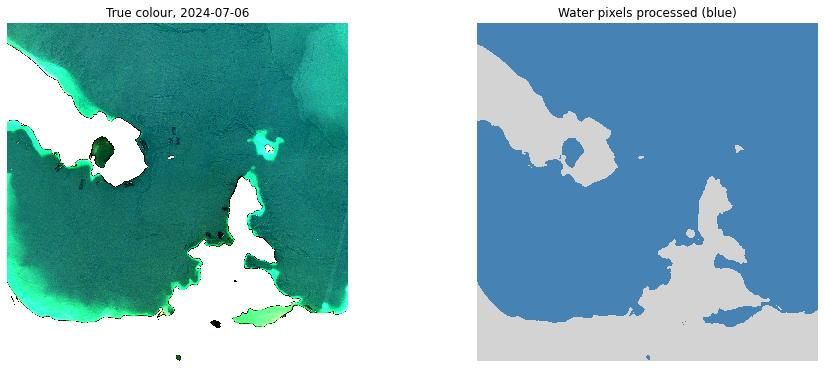

In [3]:
date = str(raster.time.dt.strftime('%Y-%m-%d').values)
fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
raster.Rrs.sel(wl=[665, 560, 490]).plot.imshow(rgb='wl', robust=True, ax=axs[0])
axs[0].set_title(f'True colour, {date}')
(raster.mask == 0).plot.imshow(ax=axs[1], cmap=mpl.colors.ListedColormap(['lightgrey', 'steelblue']),
                               add_colorbar=False)
axs[1].set_title('Water pixels processed (blue)')
for ax in axs:
    ax.set_aspect('equal')
    ax.set_axis_off()

In [4]:
odir = tempfile.mkdtemp(prefix='grsl2bgen_')
l2b_path = os.path.join(odir, 'S2B_MSIL2B_20240706T091559_N0510_R093_T34SDJ_20240706T101118.nc')

proc = GRSl2bgen.Process(raster, l2b_path=l2b_path)
%time proc.run()
print(f'L2B product: {os.path.getsize(l2b_path) / 1e6:.1f} MB')

CPU times: user 22.4 s, sys: 2.03 s, total: 24.5 s
Wall time: 18.5 s
L2B product: 17.3 MB


In [5]:
l2b = xr.open_dataset(l2b_path)
l2b

<xarray.Dataset> Size: 193MB
Dimensions:                 (x: 1200, y: 1000, Nclasses: 3)
Coordinates:
    time                    datetime64[ns] 8B ...
  * x                       (x) float64 10kB 4.812e+05 4.812e+05 ... 4.913e+05
  * y                       (y) float64 8kB 4.317e+06 4.317e+06 ... 4.307e+06
  * Nclasses                (Nclasses) int64 24B 0 1 2
    central_wavelength      float32 4B ...
Data variables: (12/18)
    spatial_ref             int64 8B ...
    owt_dist_Spyrakos2018   (Nclasses, y, x) float64 29MB ...
    owt_index_Spyrakos2018  (Nclasses, y, x) float64 29MB ...
    owt_dist_Bi2024         (y, x) float64 10MB ...
    owt_index_Bi2024        (y, x) float64 10MB ...
    owt_dist_Ta2025         (y, x) float64 10MB ...
    ...                      ...
    TURB_dogliotti          (y, x) float64 10MB ...
    SPM_nechad              (y, x) float64 10MB ...
    acdom_B15               (y, x) float64 10MB ...
    Kd_par                  (y, x) float64 10MB ...
    flags                   (y, x) int64 10MB ...
    mask                    (y, x) uint8 1MB ...
Attributes: (12/73)
    long_name:                           CA BLUE GREEN RED VRE_1 VRE_2 VRE_3 ...
    constellation:                       Sentinel-2
    constellation_id:                    S2
    product_path:                        /data/satellite/Sentinel-2/L1C/34SDJ...
    product_name:                        S2B_MSIL1C_20240706T091559_N0510_R09...
    product_filename:                    S2B_MSIL1C_20240706T091559_N0510_R09...
    ...                                  ...
    vis_swir_index_threshold:            0.0
    hcld_threshold:                      0.003
    dirdata:                             /data/grs/grsdata
    abs_gas_file:                        /home/harmel/anaconda3/envs/py12/lib...
    water_vapor_transmittance_file:      /home/harmel/anaconda3/envs/py12/lib...
    metadata_profile:                    datacube

In [6]:
rows = []
for name, da in l2b.data_vars.items():
    if name in ('flags', 'mask', 'spatial_ref'):
        continue
    values = da.values
    valid = np.isfinite(values)
    rows.append({
        'variable': name,
        'dims': ', '.join(da.dims),
        'units': da.attrs.get('units', '-'),
        'valid (%)': 100 * valid.mean(),
        'min': np.nanmin(values),
        'median': np.nanmedian(values),
        'max': np.nanmax(values),
        'description': da.attrs.get('description', da.attrs.get('definition', ''))[:70],
    })
summary = pd.DataFrame(rows).set_index('variable')
summary.style.format({'valid (%)': '{:.1f}', 'min': '{:.3g}', 'median': '{:.3g}', 'max': '{:.3g}'})

,dims,units,valid (%),min,median,max,description
variable,,,,,,,
owt_dist_Spyrakos2018,"Nclasses, y, x",radians,72.7,0.0212,0.307,1.96,
owt_index_Spyrakos2018,"Nclasses, y, x",-,72.7,1,3,13,1:OWT1: Hypereutrophic waters 2:OWT2: Common case waters 3:OWT3: Clear
owt_dist_Bi2024,"y, x",radians,72.7,0.0403,0.265,1.8,
owt_index_Bi2024,"y, x",-,72.7,1,4,10,1:1. Extremely clear and oligotrophic indigo-blue waters with high ref
owt_dist_Ta2025,"y, x",radians,72.7,0.0257,0.272,1.8,
owt_index_Ta2025,"y, x",-,72.7,1,4,16,"['1', '2', '3a', '3b', '4a', '4b', '5a', '5b', '6', '7', 'Cyanobacteria', 'Mesodinium', 'Dinoflagellates2', 'red', 'Dinoflagellates1', 'Lepidodinium']"
Chla_OC2nasa,"y, x",mg m-3,72.5,6.89e-07,2.06,1.2e+03,"Chl-a concentration from NASA OC2 with OCTS parameterization, bands 49"
Chla_M09B,"y, x",mg m-3,44.3,4.57e-05,50.3,1.2e+03,"Chl-a concentration from 705nm peak, bands 665, 705, 740 nm"
Chla_NIRB,"y, x",mg m-3,71.9,0,1.28,1.2e+03,"Chl-a concentration from 705/443 ratio, bands 443, 705 nm"


In [7]:
def show(ax, da, title, **kwargs):
    """Map one variable with equal aspect and no axes."""
    cbar_kwargs = {'shrink': 0.8, 'label': kwargs.pop('label', da.attrs.get('units', ''))}
    if 'ticks' in kwargs:
        cbar_kwargs['ticks'] = kwargs.pop('ticks')
    da.plot.imshow(ax=ax, cbar_kwargs=cbar_kwargs, **kwargs)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_axis_off()

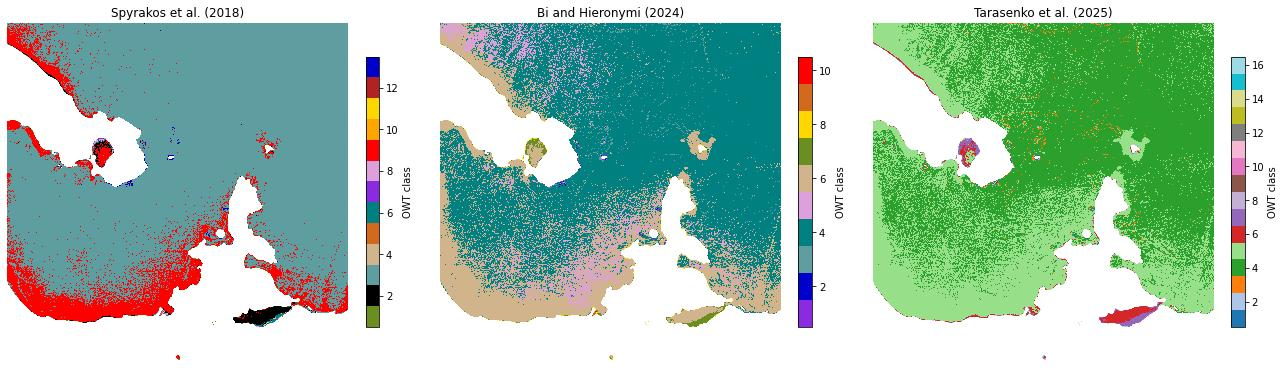

In [8]:
cmap_spy = GRSl2bgen.OWT(raster, owt_database='Spyrakos2018').cmap_owt
cmap_bi = GRSl2bgen.OWT(raster, owt_database='Bi2024', param='m_Rrs').cmap_owt
cmap_ta = plt.get_cmap('tab20', 16)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, var, n, cmap, title in [
        (axs[0], l2b.owt_index_Spyrakos2018.isel(Nclasses=0), 13, cmap_spy, 'Spyrakos et al. (2018)'),
        (axs[1], l2b.owt_index_Bi2024, 10, cmap_bi, 'Bi and Hieronymi (2024)'),
        (axs[2], l2b.owt_index_Ta2025, 16, cmap_ta, 'Tarasenko et al. (2025)')]:
    show(ax, var, title, cmap=cmap, vmin=0.5, vmax=n + 0.5, label='OWT class')

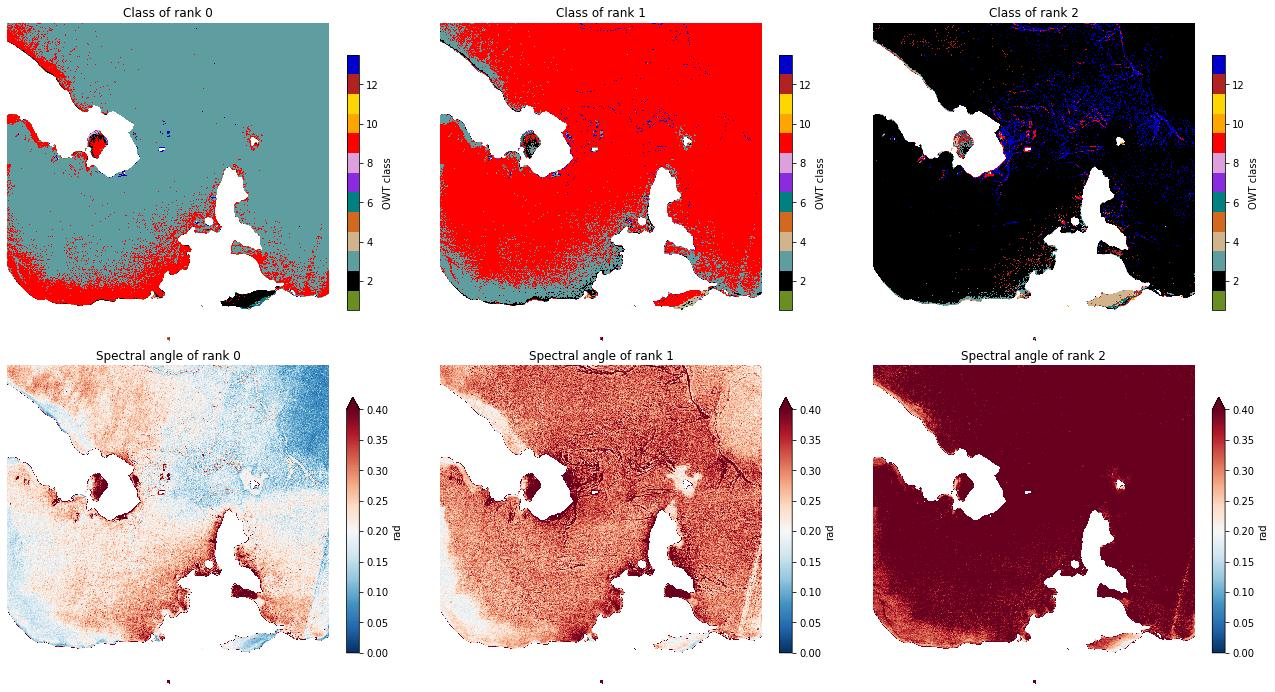

In [9]:
fig, axs = plt.subplots(2, 3, figsize=(18, 9.5), constrained_layout=True)
for k in range(3):
    show(axs[0, k], l2b.owt_index_Spyrakos2018.isel(Nclasses=k), f'Class of rank {k}',
         cmap=cmap_spy, vmin=0.5, vmax=13.5, label='OWT class')
    show(axs[1, k], l2b.owt_dist_Spyrakos2018.isel(Nclasses=k), f'Spectral angle of rank {k}',
         cmap='RdBu_r', vmin=0, vmax=0.4, label='rad')

In [10]:
pixel_area_km2 = abs(float(l2b.x[1] - l2b.x[0]) * float(l2b.y[1] - l2b.y[0])) * 1e-6
best = l2b.owt_index_Spyrakos2018.isel(Nclasses=0).values.ravel()
best = best[np.isfinite(best)].round().astype(int)
classes, counts = np.unique(best, return_counts=True)
pd.DataFrame({'OWT': classes,
              'pixels': counts,
              'area (km2)': counts * pixel_area_km2,
              'share (%)': 100 * counts / counts.sum()}).set_index('OWT').round(2)

,pixels,area (km2),share (%)
OWT,,,
1,1547,0.13,0.18
2,8983,0.75,1.03
3,750252,62.96,86.01
4,317,0.03,0.04
5,135,0.01,0.02
6,1310,0.11,0.15
7,421,0.04,0.05
8,581,0.05,0.07
9,106866,8.97,12.25


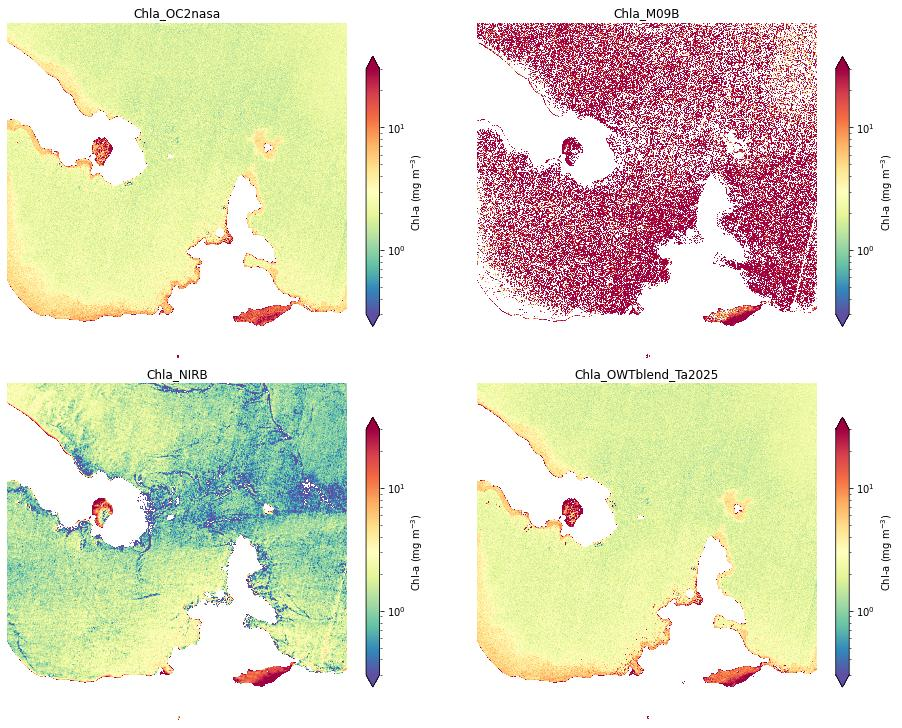

In [11]:
chl_vars = ['Chla_OC2nasa', 'Chla_M09B', 'Chla_NIRB', 'Chla_OWTblend_Ta2025']
norm = mpl.colors.LogNorm(vmin=0.3, vmax=30)
fig, axs = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
for ax, var in zip(axs.ravel(), chl_vars):
    show(ax, l2b[var], var, cmap='Spectral_r', norm=norm, label='Chl-a (mg m$^{-3}$)')

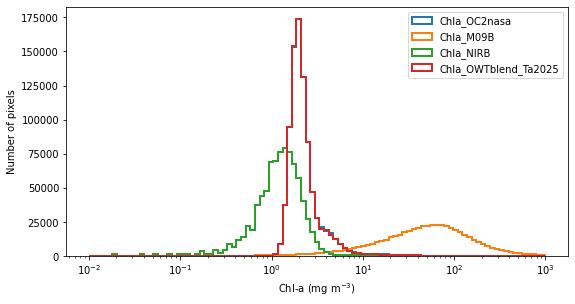

In [12]:
bins = np.logspace(-2, 3, 100)
fig, ax = plt.subplots(figsize=(9, 4.5))
for var in chl_vars:
    values = l2b[var].values.ravel()
    ax.hist(values[np.isfinite(values)], bins=bins, histtype='step', lw=2, label=var)
ax.set_xscale('log')
ax.set_xlabel('Chl-a (mg m$^{-3}$)')
ax.set_ylabel('Number of pixels')
ax.legend();

In [13]:
best_class = l2b.owt_index_Spyrakos2018.isel(Nclasses=0).round().rename('OWT')
median_chl = l2b.Chla_OWTblend_Ta2025.groupby(best_class).median().to_series()
median_chl.index = median_chl.index.astype(int)
median_chl.rename('median Chl-a (mg m-3)').round(2).to_frame()

,median Chl-a (mg m-3)
OWT,
1,145.88
2,13.61
3,1.97
4,22.52
5,32.06
6,44.27
7,93.88
8,119.99
9,4.00


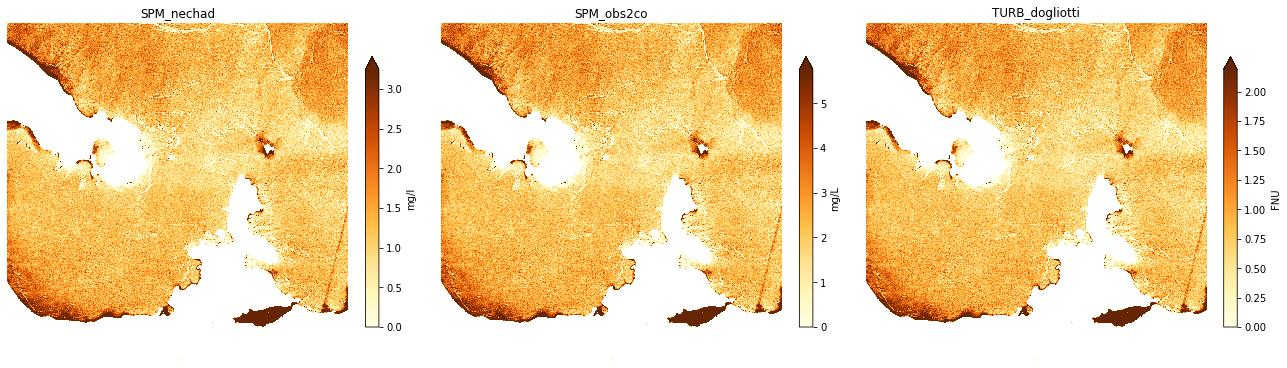

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, var in zip(axs, ['SPM_nechad', 'SPM_obs2co', 'TURB_dogliotti']):
    show(ax, l2b[var], var, cmap='YlOrBr', robust=True)

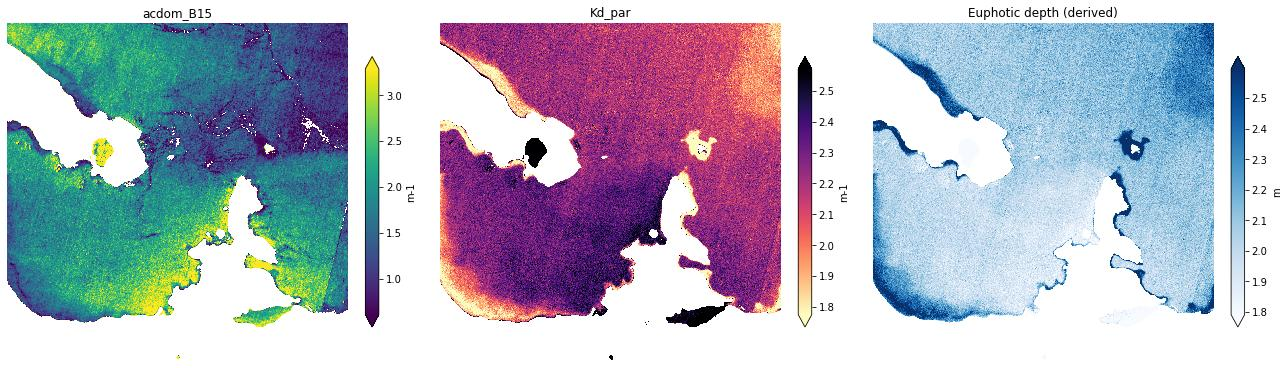

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
show(axs[0], l2b.acdom_B15, 'acdom_B15', cmap='viridis', robust=True)
show(axs[1], l2b.Kd_par, 'Kd_par', cmap='magma_r', robust=True)
show(axs[2], (np.log(100) / l2b.Kd_par).rename('z_eu'), 'Euphotic depth (derived)',
     cmap='Blues', robust=True, label='m')

In [16]:
names = l2b.flags.attrs['flag_names']
names = ast.literal_eval(names) if isinstance(names, str) else list(names)
flags = l2b.flags.values.astype(np.int64)

table = []
for bit, name in enumerate(names):
    if name == 'None':
        continue
    is_set = (flags >> bit) & 1
    table.append({'bit': bit, 'value': 2 ** bit, 'flag': name, 'pixels (%)': 100 * is_set.mean()})
pd.DataFrame(table).set_index('bit').round(2)

,value,flag,pixels (%)
bit,,,
0,1,nodata,0.00
1,2,cloud_p06,0.43
2,4,cloud_p08,0.01
3,8,water_swir_visible_index,73.00
4,16,water_red_visible_index,73.30
5,32,thin_cirrus,0.00
6,64,opac_cirrus,0.00
7,128,high_swir,6.21
8,256,surfwater_land,0.00


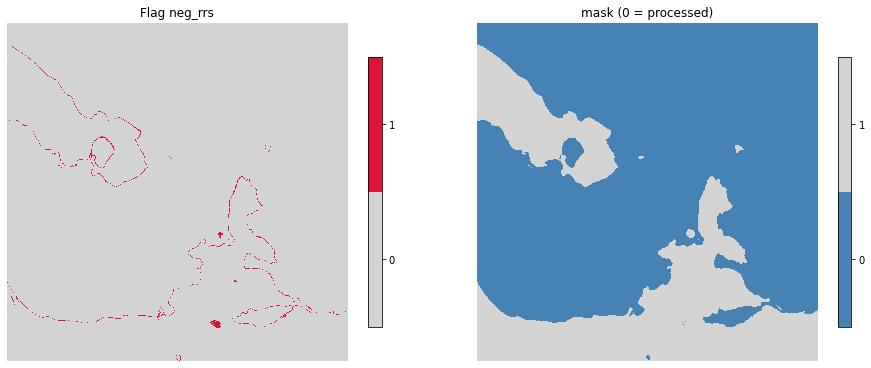

In [17]:
bit = names.index('neg_rrs')
fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
show(axs[0], ((l2b.flags.astype('int64') >> bit) & 1).rename('neg_rrs'), 'Flag neg_rrs',
     cmap=mpl.colors.ListedColormap(['lightgrey', 'crimson']), vmin=-0.5, vmax=1.5, ticks=[0, 1], label='')
show(axs[1], l2b.mask, 'mask (0 = processed)',
     cmap=mpl.colors.ListedColormap(['steelblue', 'lightgrey']), vmin=-0.5, vmax=1.5, ticks=[0, 1], label='')

In [18]:
pd.DataFrame({var: {k: l2b[var].encoding.get(k) for k in ['dtype', 'scale_factor', 'add_offset', '_FillValue']}
              for var in ['Chla_OWTblend_Ta2025', 'SPM_nechad', 'Kd_par']}).T

,dtype,scale_factor,add_offset,_FillValue
Chla_OWTblend_Ta2025,int16,0.018279,598.938006,-32768
SPM_nechad,int16,0.001574,51.584873,-32768
Kd_par,int16,0.000328,11.34848,-32768


In [19]:
zarr_path = os.path.join(odir, 'S2B_MSIL2B_20240706T091559_N0510_R093_T34SDJ_20240706T101118.zarr')
proc.l2b.export_to_zarr_pyramid(zarr_path, min_size=128)

levels = sorted(d for d in os.listdir(zarr_path) if d.isdigit())
for level in levels:
    with xr.open_zarr(zarr_path, group=level) as ds:
        dx, dy = abs(float(ds.x[1] - ds.x[0])), abs(float(ds.y[1] - ds.y[0]))
        print(f'level {level}: {ds.sizes["y"]} x {ds.sizes["x"]} pixels of {dx:.1f} x {dy:.1f} m')

level 0: 1000 x 1200 pixels of 8.4 x 10.0 m
level 1: 500 x 600 pixels of 16.8 x 20.0 m
level 2: 250 x 300 pixels of 33.6 x 40.0 m


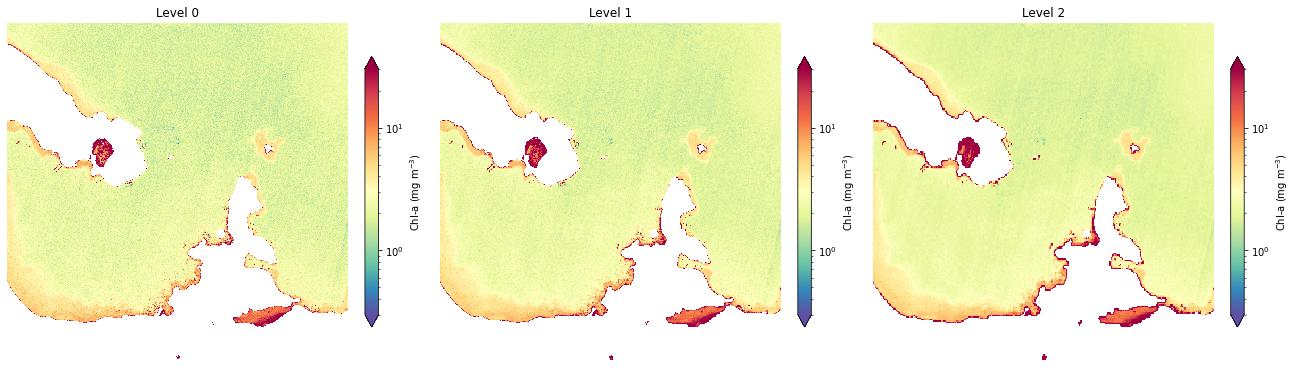

In [20]:
fig, axs = plt.subplots(1, len(levels), figsize=(6 * len(levels), 5), constrained_layout=True)
for ax, level in zip(axs, levels):
    with xr.open_zarr(zarr_path, group=level) as ds:
        show(ax, ds.Chla_OWTblend_Ta2025.load(), f'Level {level}', cmap='Spectral_r',
             norm=mpl.colors.LogNorm(vmin=0.3, vmax=30), label='Chl-a (mg m$^{-3}$)')

In [21]:
l2b.close()
shutil.rmtree(odir)